In [2]:
pip install scipy

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import scipy
print(scipy.__version__)

1.17.1


In [138]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from scipy.integrate import trapezoid as trapz

1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


In [33]:
#Fill a numpy array, x, of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
N = 200
mu = 0 #mean numa dist normal centrada em 0, a media tende a zero
sigma = 1 #standard deviation
x = np.random.normal(mu,sigma,N)
print(x)

[-1.13675024 -0.05644595 -1.88886601  0.86052811 -0.78159696  1.36838068
 -0.00392657  1.19130345  0.04255733  1.22837525  1.22331559  0.45179008
  0.38366996  1.64682807 -0.03321468  1.36030578 -0.76496314  1.13981089
 -0.88759676  0.77530493  0.48669937 -1.50470725  1.32724431  1.37070891
  1.20050034  0.50647516  0.30093673 -1.58414845 -0.45866369 -0.91673007
  0.04623581 -0.45875726 -0.88074283 -0.49050095 -1.35848083 -0.1582602
 -0.69963094  0.36318028  0.31713791 -1.54257322  1.43261466  0.77617806
  0.0705426  -0.29571522  0.29041469  2.39980213 -1.05299203  1.02125421
 -0.42319213 -1.25600238  1.6793452  -1.32132773  0.31919601  0.28170053
  1.45009977 -0.20095913 -0.03628296  1.97907052  0.24299817  0.12437025
 -0.59960545  0.33936631 -0.52513161  0.54126354  0.46835931  0.8239841
  0.99952251 -1.12535086  0.2902864   1.28470778  0.31164382 -0.68723371
 -0.05925755 -0.62277917 -1.63714522  0.77700496  1.02931257 -0.81417757
  0.26931385  0.76334682  0.47759994  0.43204617 -0.7

([<matplotlib.axis.YTick at 0x219099fc6d0>,
 [Text(0, 0.0, '0'),
  Text(0, 3.0, '3'),
  Text(0, 6.0, '6'),
  Text(0, 9.0, '9'),
  Text(0, 12.0, '12'),
  Text(0, 15.0, '15'),
  Text(0, 18.0, '18'),
  Text(0, 21.0, '21'),
  Text(0, 24.0, '24'),
  Text(0, 27.0, '27')])

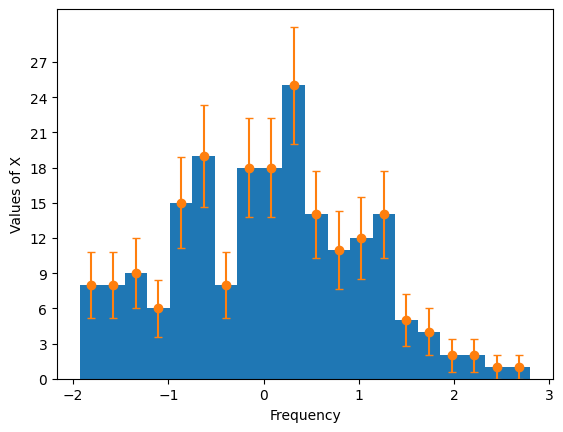

In [48]:
counts, edges = np.histogram(x, bins=20, density=False) #faço isso para obter os counts e edges
centers = 0.5*(edges[1:] + edges[:-1])
errors = np.sqrt(counts)

plt.hist(x, bins=20, histtype = 'bar') #ploto o histograma
plt.errorbar(centers, counts, yerr=errors, fmt='o',capsize=3) #ploto o error bar sobreposto, baseado nos centros e contagem
plt.xlabel('Frequency')
plt.ylabel('Values of X')
plt.xticks(np.arange(np.floor(min(x)), np.ceil(max(x))+1,1))
plt.yticks(np.arange(0, max(counts)+max(errors),3))

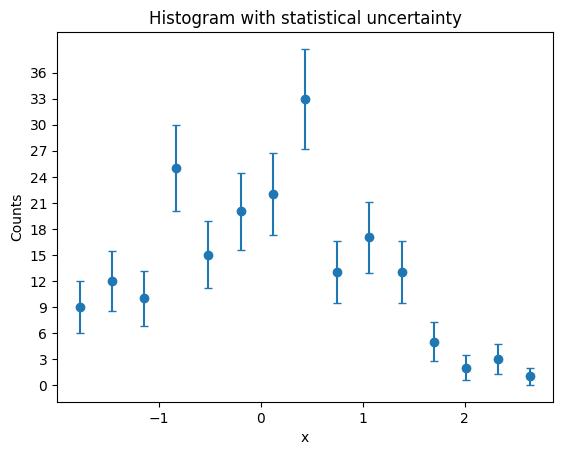

In [52]:
counts, edges = np.histogram(x, bins=15, density=False)

centers = 0.5*(edges[1:] + edges[:-1])
errors = np.sqrt(counts)

plt.errorbar(
    centers, counts,
    yerr=errors,
    fmt='o',
    capsize=3
)

plt.xlabel("x")
plt.ylabel("Counts")
plt.yticks(np.arange(0, max(counts)+max(errors),3))
plt.title("Histogram with statistical uncertainty")
plt.show()


In [51]:
#for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned.
#to tune a parameter: pode ser controlado, regulado ou mexido; vai indicar a suavidade da gaussian
h = 1.06 * np.std(x) * N**(-1/5) #formula dada no exercicio
gaussians=[]
#for xi in x:
#    g = norm.pdf(x, loc=xi, scale=h)
#    gaussians.append(g)
gaussians = [norm.pdf(x,loc=xi,scale=h) for xi in x]
kde = np.sum(gaussians, axis=0)

area_hist = np.sum(counts)   # total de eventos = N
area_kde = trapz(kde, x)
kde_norm = kde * area_hist / area_kde

In [93]:
# for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
# 1.06 * x.std() * x.size ^{-\frac{1}{5.}}  you can use the scipy function `stats.norm()` for that.

stdef = 1.06 * np.std(x) * x* N**(-0.2)
gaussian = [norm(loc=i,scale=stdef) for i in x]
kdet = np.sum(gaussian, axis=0)
area_hist = np.sum(counts)   # total de eventos = N
area_kdet = trapz(kdet, x)
kde_norm = kdet * area_hist / area_kdet
#grid = np.linspace(x.min()-3*sigma, x.max()+3*sigma, 200) #criar um “grid” (eixo x contínuo) para avaliar as gaussians
#gauss_values = np.array([g.pdf(grid) for g in gaussian]) #transforma cada distribuição em valores numéricos
#density = np.sum(gauss_values, axis=0) #soma das gaussianas

# normalização para bater com histograma
#area_kde = trapz(density, grid)
#density *= len(x) / area_kde


TypeError: unsupported operand type(s) for +: 'rv_continuous_frozen' and 'rv_continuous_frozen'

Text(0.5, 1.0, 'KDE (manual)')

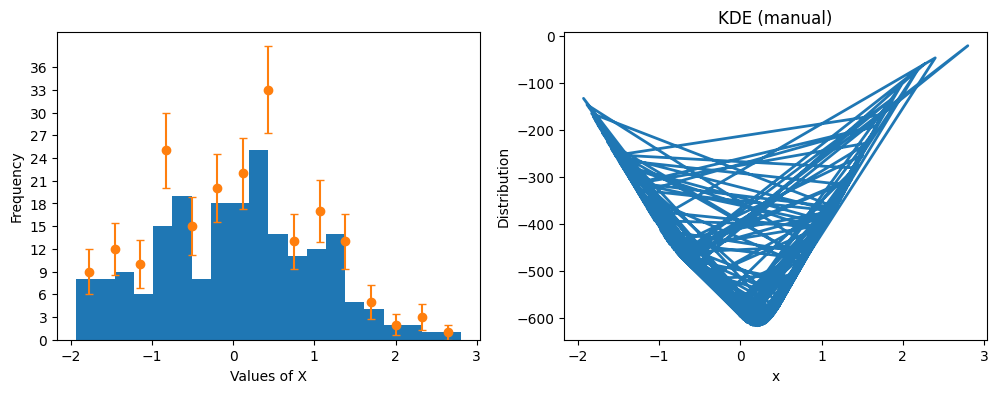

In [94]:
#in a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
#Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of 
#the original histogram. For that you could use the scipy.integrate.trapz() method

fig, axes = plt.subplots(1,2,figsize=(12,4))#1 linha, 2 colunas
#axes[0] : o primeiro, ploto o que ue ja tinha
axes[0].hist(x, bins=20, histtype = 'bar') #ploto o histograma
axes[0].errorbar(centers, counts, yerr=errors, fmt='o',capsize=3) #ploto o error bar sobreposto, baseado nos centros e contagem
axes[0].set_xlabel('Values of X')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(np.arange(np.floor(min(x)), np.ceil(max(x))+1,1))
axes[0].set_yticks(np.arange(0, max(counts)+max(errors),3))

#axes[1]: o segundo, ploto o novo que está sendo pedido

axes[1].plot(x, kde_norm, linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("Distribution")
axes[1].set_title("KDE (manual)")

Text(0.5, 1.0, 'KDE (manual)')

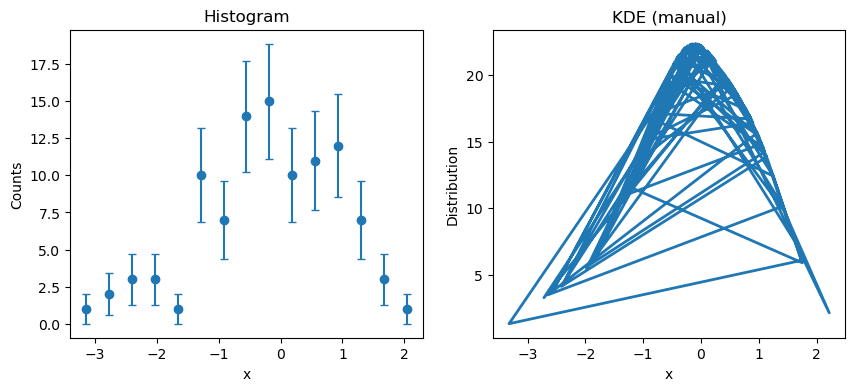

In [100]:

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].errorbar(
    centers,
    counts,
    yerr=errors,
    fmt='o',
    capsize=3)
axes[0].set_xlabel("x")
axes[0].set_ylabel("Counts")
axes[0].set_title("Histogram")

axes[1].plot(x, kde_norm, linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("Distribution")
axes[1].set_title("KDE (manual)")


2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

In [120]:
#Write a function that generate a 2D datasets of 2 categories. 
#Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)

def datagen(mu1,mu2,sig1,sig2,N1,N2):
    #usando np.random.normal(mu,sigma,size) para criar as normais de distribuição
    x1 = np.random.normal(mu1, sig1, N1)
    y1 = np.random.normal(mu1, sig1, N1)

    x2 = np.random.normal(mu2, sig2, N2)
    y2 = np.random.normal(mu2, sig2, N2)
    
    #uso o column stack para transformar esses arrays em algo 2D (x1i,y1i)
    cat1 = np.column_stack((x1,y1))
    cat2 = np.column_stack((x2,y2))

    #Criar o label (como se fosse features e target; tg1 = 0; tg2 = 1)
    label1 = np.zeros(N1)
    label2 = np.ones(N2)

    #juntar todos os dados para plotar num unico grafico
    cat = np.vstack((cat1,cat2))
    lab = np.hstack((label1,label2))

    return cat, lab

In [108]:
def generating(m1,m2,st1,st2,len1,len2):
    x11 = np.random.normal(m1,st1,len1)
    x12 = np.random.normal(m1,st1,len1)
    x1 = np.column_stack((x11,x12))

    x21 = np.random.normal(m2,st2,len2)
    x22 = np.random.normal(m2,st2,len2)
    x2 = np.column_stack((x21,x22))

    y1 = np.zeros(len1)
    y2 = np.ones(len2)

    x = np.vstack((x1,x2))
    y = np.hstack((y1,y2))

    return x,y

In [109]:
x,y = generating(1,5,1,0,300,200)

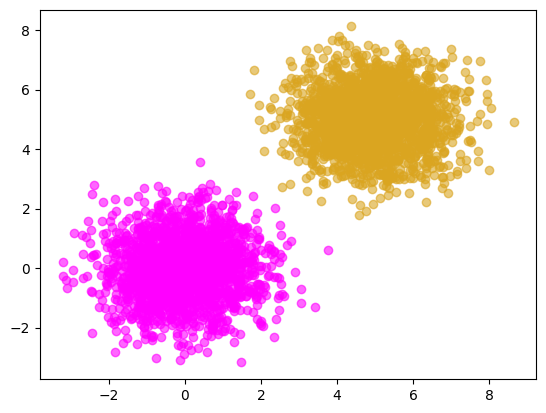

In [124]:
x, y = datagen(0,5,1,1,2000,2030)

plt.scatter(
    x[y == 0, 0], x[y == 0, 1], #x is 2d, so i plot x[0] (x11) WHERE Y==0  and x[1](x12) WHERE Y==0
    color='fuchsia', alpha=0.6, label='Class 0')

plt.scatter(
    x[y == 1, 0], x[y == 1, 1],
    color='goldenrod', alpha=0.6, label='Class 1')

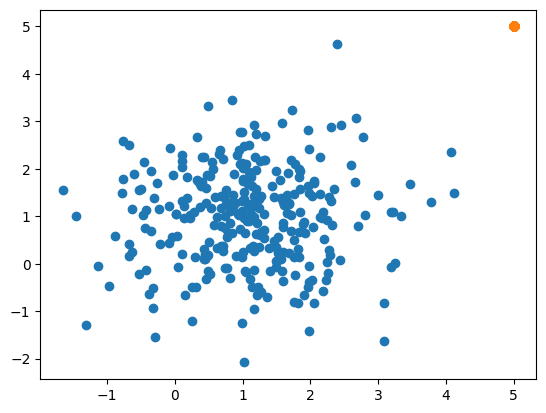

In [116]:
plt.scatter(x[y==0,0],x[y==0,1])
plt.scatter(x[y==1,0],x[y==1,1])

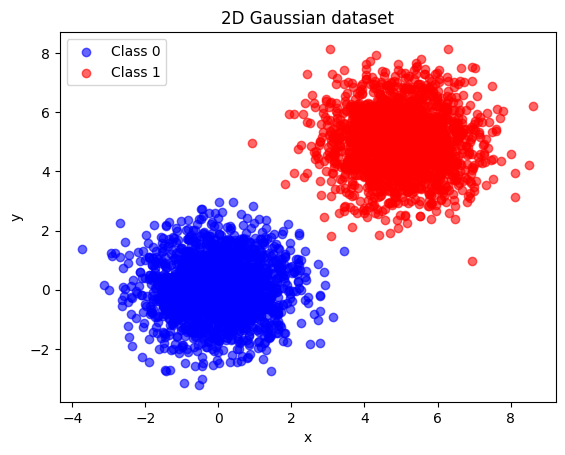

In [121]:
cat, lab = datagen(0,5,1,1,2000,2030)

plt.scatter(
    cat[lab == 0, 0], cat[lab == 0, 1], #plot x where ladel is zero then plot y for label = 0
    color='blue', alpha=0.6, label='Class 0')

plt.scatter(
    cat[lab == 1, 0], cat[lab == 1, 1],
    color='red', alpha=0.6, label='Class 1')

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Gaussian dataset")
plt.legend()
plt.show()


In [125]:
import wget
from IPython.display import Image

In [132]:
ims = wget.download('https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png')

-1 / unknown

In [101]:
Image('two_categories_scatter_plot.png')

! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

In [130]:
prof = wget.download('https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy?dl=1')

100% [............................................................................] 252081 / 252081

In [142]:
data = np.load(prof, allow_pickle=True).item()
#np.load: Essa função lê o arquivo .npy e devolve um objeto NumPy. (POIS ERA UM DICIONARIO)
# np.item(): como esse array possui apenas um único objeto dentro dele (o dicionário), usamos para extrair esse objeto.
#Agora o pandas transforma o dicionário em tabela.

In [150]:
dataf = pd.DataFrame(data)

dataf.head(30)

,residuals,distances
0,1.100000,16.0
1,-1.950000,6.3
2,-7.200000,3.4
3,-4.150000,8.4
4,-6.590000,1.7
5,-11.020000,4.4
6,-2.270000,0.6
7,-2.160000,19.0
8,-0.042857,3.3
9,0.128571,5.3


In [152]:
#Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
dataf = dataf[np.abs(dataf['residuals']) < 2] #dataf = dataf[aplicar meu filtro] -> filtro: np.abs de residuals < 2

In [154]:
dataf.head()

,residuals,distances
0,1.100000,16.0
1,-1.950000,6.3
8,-0.042857,3.3
9,0.128571,5.3
10,0.085714,15.0


In [156]:
#perform a linear regression of "residuals" versus "distances" using scipy.stats.linregress()
from scipy.stats import linregress

result = linregress(dataf['distances'],dataf['residuals']) #linregress(x,y)

In [157]:
print(result)

LinregressResult(slope=np.float64(0.0032597701220305757), intercept=np.float64(-0.15432816763069465), rvalue=np.float64(0.043403510522559044), pvalue=np.float64(8.717037183576572e-06), stderr=np.float64(0.000732701400844578), intercept_stderr=np.float64(0.008458951961471827))


In [159]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


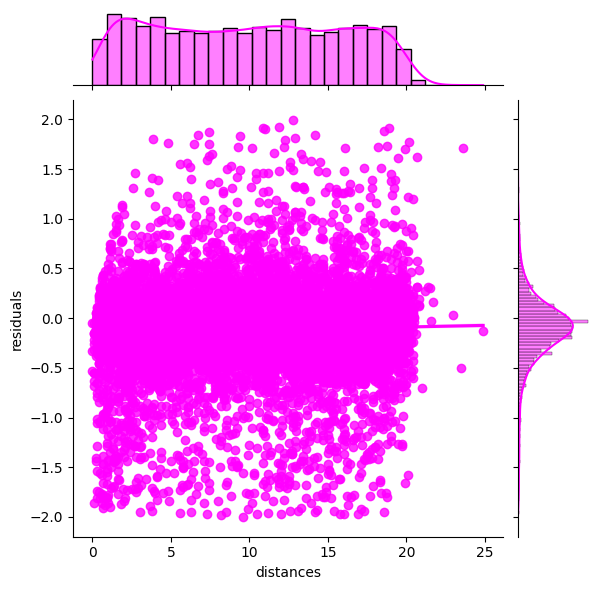

In [190]:
#plot a seaborn jointplot of "residuals" versus "distances", having seaborn performing a linear regression. 
#The result of the regression should be displayed on the plot
import seaborn as sns

sns.jointplot(
    data=dataf,
    x="distances",
    y="residuals",
    kind="reg",
    color='fuchsia'
)

In [184]:
#x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
#y, the mean values of the "residuals", estimated in slices (bins) of "distance"
#erry, the standard deviation of the of the "residuals", estimated in slices (bins) of "distance"
bins = np.linspace(0, 20, 21)  # 20 bins
bin_centers = 0.5 * (bins[:-1] + bins[1:]) 

x = bin_centers #definimos o x como os centros dos bins

#criamos listas para atribuir os dados
y = []
erry = []

for i in range(len(bins)-1): #rodar a quantidade de bins 
    mask=(dataf['distances'] >= bins[i]) & (dataf['distances'] < bins[i+1]) #analisando se estra entre uma bin ou outra 
    bin_data = dataf.loc[mask,'residuals'] #atribui o ponto de residuals no bin

    if len(bin_data) > 0:
        y.append(bin_data.mean()) #se os pontos forem atribuidos: append o mean e std
        erry.append(bin_data.std())
    else:
        y.append(np.nan)
        erry.append(np.nan)

x = np.array(x)
y = np.array(y)
erry = np.array(erry)

In [185]:
print(erry)

[0.48576155 0.42803951 0.4250441  0.40964586 0.39026555 0.39313766
 0.4459799  0.45432505 0.44370592 0.40508698 0.43882926 0.48141583
 0.50415864 0.45683832 0.45216187 0.46115892 0.43144405 0.42638868
 0.40944766 0.38053331]


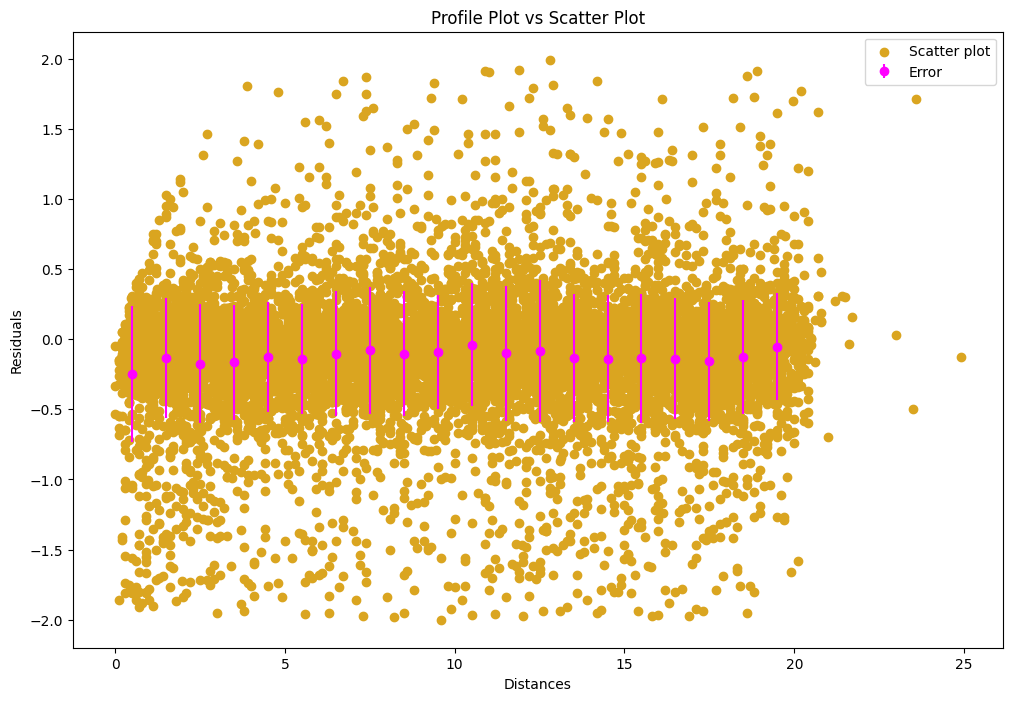

In [189]:
plt.figure(figsize=(12,8))
plt.scatter(dataf['distances'],dataf['residuals'], color='goldenrod', label='Scatter plot')
plt.errorbar(x, y, yerr=erry, fmt='o', color='fuchsia', label='Error')

plt.xlabel("Distances")
plt.ylabel("Residuals")
plt.title("Profile Plot vs Scatter Plot")
plt.legend()
plt.show()

In [170]:
data_array=np.load('residuals_261.npy',allow_pickle=True).item()
df=pd.DataFrame(data_array)

df.columns= ['residual','distance']
df=df[df['residual'].abs() <2].copy()

slope,intercept,r_value,p_value,std_error =stats.linregress(df['distance'],df['residual'])
print(f"Regression result: Slope= {slope:.4f}, Intercept= {intercept:.4f}")

sns.jointplot (data=df,x='distance',y= 'residual',kind='reg',
                scatter_kws={'alpha': 0.1, 'color': 'gray'}, line_kws={'color': 'blue'})
plt.show()

bins=np.linspace(0,20,21)
bin_centers=(bins[:-1]+bins[1:])/2

x_prof=bin_centers
y_prof=[]
err_prof=[]

for i in range(len(bins)-1):
    mask=(df['distance'] >= bins[i]) & (df['distance'] < bins[i+1])
    bin_data=df.loc[mask,'residual']

    if len(bin_data) >0 :
        y_prof.append(bin_data.mean())
        err_prof.append(bin_data.std())
    else:
        y_prof.append(np.nan)
        err_prof.append(np.nan)

x_prof = np.array(x_prof)
y_prof = np.array(y_prof)
err_prof = np.array(err_prof)

plt.figure(figsize=(10, 6))
plt.scatter(df['distance'], df['residual'], alpha=0.1, color='gray', label='Data Scatter')
plt.errorbar(x_prof, y_prof, yerr=err_prof, fmt='o-', color='red', 
             ecolor='black', capsize=3, label='Profile Plot (Mean ± Std)')

plt.xlabel("Distances")
plt.ylabel("Residuals")
plt.title("Profile Plot vs Scatter Plot")
plt.legend()
plt.grid(True)
plt.show()

20
21
21
